<a href="https://colab.research.google.com/github/Ahbar1999/mtp-pimsimulator/blob/phase-2/PIM_ThermalSim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RRAM Crossbar Thermal Crosstalk and Conductance Drift Simulator
Based on: Pande et al., 'Thermal Crosstalk Analysis in RRAM
          Passive Crossbar Arrays', arXiv:2304.01439

Simulation Parameters:
  Array Size: 32 × 32
  Cell Spacing: 200 nm
  Read Voltage: 0.3 V
  Inference Cycles: 200,000

input_data shape: (200, 32)
ideal_outputs shape: (200, 32)
Running 200000 inference cycles...
Array size: (32, 32), Spacing: 200nm
----------------------------------------------------------------------
----------------------------------------------------------------------
Simulation complete!

Generating visualizations...

Plot saved as 'rram_degradation_analysis.png'


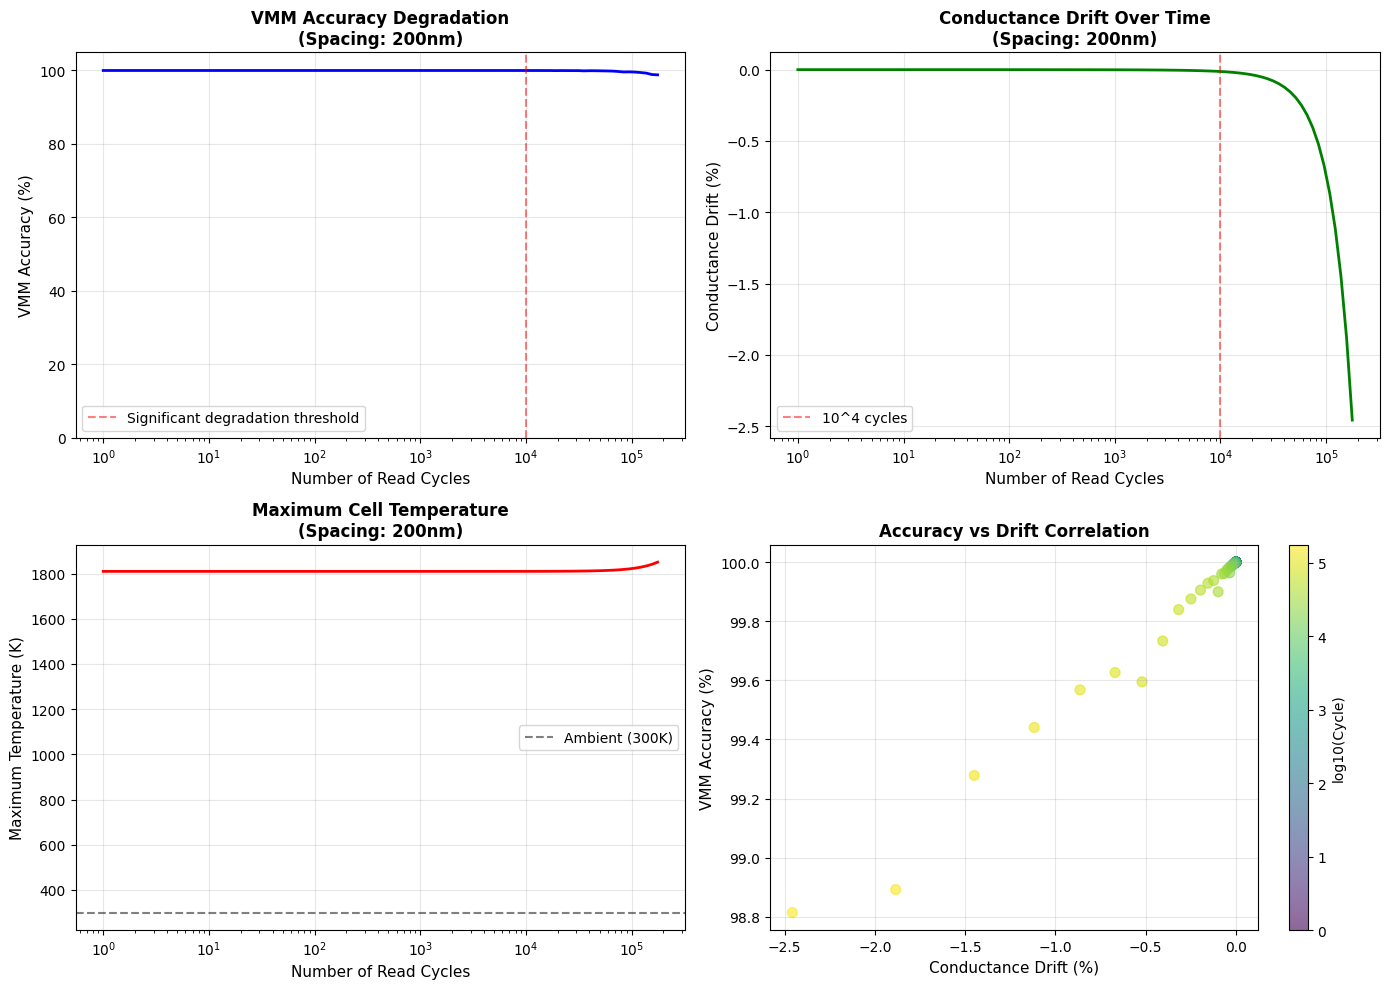


SIMULATION SUMMARY
Initial Accuracy:        100.00%
Final Accuracy:          98.81%
Accuracy Loss:           1.19%
Final Conductance Drift: -2.46%
Maximum Temperature:     1850.5 K (ΔT = 1550.5 K)
Cycles Simulated:        200,000

SPACING COMPARISON STUDY

Simulating spacing: 80nm
input_data shape: (100, 16)
ideal_outputs shape: (100, 16)
Running 100000 inference cycles...
Array size: (16, 16), Spacing: 80nm
----------------------------------------------------------------------
----------------------------------------------------------------------
Simulation complete!

Simulating spacing: 160nm
input_data shape: (100, 16)
ideal_outputs shape: (100, 16)
Running 100000 inference cycles...
Array size: (16, 16), Spacing: 160nm
----------------------------------------------------------------------
----------------------------------------------------------------------
Simulation complete!

Simulating spacing: 240nm
input_data shape: (100, 16)
ideal_outputs shape: (100, 16)
Running 100000 in

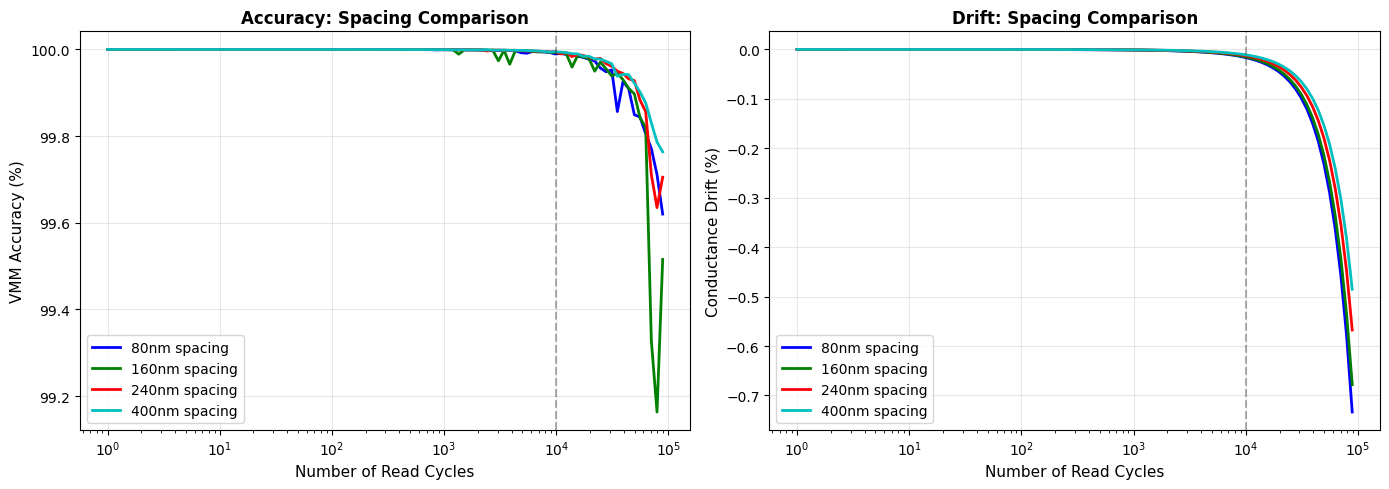


All simulations complete!


In [18]:

"""
RRAM Crossbar Thermal Crosstalk and Conductance Drift Simulator
Based on: "Thermal Crosstalk Analysis in RRAM Passive Crossbar Arrays"
          by Shubham Pande, Bhaswar Chakrabarti, Anjan Chakravorty
"""

import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, List

# ============================================================================
# 1. THERMAL CROSSTALK MODEL
# ============================================================================

class ThermalCrosstalkModel:
    """
    Models thermal crosstalk in RRAM crossbar arrays based on steady-state
    thermal resistance and coupling coefficients.

    Reference: Section III of the paper
    """

    def __init__(self, array_size: Tuple[int, int], spacing_nm: float):
        """
        Initialize thermal crosstalk model.

        Parameters:
        -----------
        array_size : tuple (rows, cols)
            Size of RRAM crossbar array
        spacing_nm : float
            Spacing between adjacent cells in nanometers
        """
        self.array_size = array_size
        self.rows, self.cols = array_size
        self.spacing = spacing_nm
        self.T_ambient = 300  # K (ambient temperature)

        # Compute thermal parameters
        self.Rth = self._compute_thermal_resistance()
        self.TC_matrix = self._compute_coupling_matrix()

    def _compute_thermal_resistance(self) -> np.ndarray:
        """
        Compute position-dependent thermal resistance for each cell.

        From paper: Corner cells have higher Rth (~5.8e6 K/W) than
        center cells (~5.4e6 K/W) due to different distances to heat sink.

        Reference: Fig. 5 (Right) in paper

        Returns:
        --------
        Rth : ndarray (rows, cols)
            Thermal resistance matrix in K/W
        """
        Rth = np.zeros((self.rows, self.cols))

        # Rth depends on distance from edges (corner cells dissipate heat slower)
        for i in range(self.rows):
            for j in range(self.cols):
                # Minimum distance to any edge
                edge_dist = min(i, self.rows-1-i, j, self.cols-1-j)

                # Corner cells (edge_dist=0) have highest Rth
                # Center cells have lowest Rth
                # Linear approximation based on paper's Fig 5
                Rth[i, j] = 5.8e6 - edge_dist * 0.13e6

        return Rth

    def _compute_coupling_matrix(self) -> np.ndarray:
        """
        Compute thermal coupling coefficient matrix.

        Definition:
          'the coupling coefficient c12(TC[i][j]) is the quotient of the
          temperature rises at cell#1 and #2 for the case where cell#1
          is switched off, and cell#2 is switched on.'

        From paper: TC characterizes the impact of self-heating of cell#2
        on temperature rise of cell#1. Cells sharing electrode lines have
        maximum coupling. TC varies with spacing (Fig 6).

        Reference: Section III.B and Fig. 6 in paper

        Returns:
        --------
        TC : ndarray (n_cells, n_cells)
            Thermal coupling matrix
        """
        n_cells = self.rows * self.cols
        TC = np.zeros((n_cells, n_cells))

        # Approximate TC from Fig 6 (left) - spacing dependent
        # TC for immediate neighbors along electrode lines
        if self.spacing <= 80:
            tc_neighbor = 0.50
        elif self.spacing <= 160:
            tc_neighbor = 0.45
        elif self.spacing <= 240:
            tc_neighbor = 0.35
        elif self.spacing <= 320:
            tc_neighbor = 0.30
        elif self.spacing <= 400:
            tc_neighbor = 0.27
        else:
            tc_neighbor = 0.25

        # Build coupling matrix based on cell positions
        for i in range(self.rows):
            for j in range(self.cols):
                cell_idx = i * self.cols + j

                # Cells in same row (share top electrode) - strongest coupling
                for j2 in range(self.cols):
                    if j2 != j:
                        neighbor_idx = i * self.cols + j2
                        dist = abs(j2 - j)
                        # Coupling decreases with distance
                        TC[cell_idx, neighbor_idx] = tc_neighbor / dist

                # Cells in same column (share bottom electrode) - strong coupling
                for i2 in range(self.rows):
                    if i2 != i:
                        neighbor_idx = i2 * self.cols + j
                        dist = abs(i2 - i)
                        TC[cell_idx, neighbor_idx] = tc_neighbor / dist

                # Diagonal neighbors (no shared electrode) - weak coupling
                for di in [-1, 0, 1]:
                    for dj in [-1, 0, 1]:
                        if di == 0 and dj == 0:
                            continue
                        i2, j2 = i + di, j + dj
                        if 0 <= i2 < self.rows and 0 <= j2 < self.cols:
                            if di != 0 and dj != 0:  # Diagonal
                                neighbor_idx = i2 * self.cols + j2
                                # Much weaker coupling for diagonal cells
                                '''Magic Number: 0.1 = Heuristic weight for distant effect(very less affected)'''
                                TC[cell_idx, neighbor_idx] = tc_neighbor * 0.1

        # Main diagonal is 1 (self-coupling)
        np.fill_diagonal(TC, 1.0)

        return TC

    def compute_temperature_rise(self, conductance_state: np.ndarray,
                                voltage_read: float) -> np.ndarray:
        """
        Compute steady-state temperature rise for all cells including
        thermal crosstalk effects.

        From paper (Eq. 3-6):
        ΔT_i = P_diss_i × Rth_i + Σ(TC_ij × ΔT_j)

        This is solved as: ΔT = TC_matrix @ ΔT_self
        where ΔT_self = P_diss × Rth

        Parameters:
        -----------
        conductance_state : ndarray (rows, cols)
            Current conductance values of all cells
        voltage_read : float
            Applied read voltage

        Returns:
        --------
        DT_total : ndarray (rows, cols)
            Temperature rise (ΔT) for each cell in Kelvin
        """
        G_flat = conductance_state.flatten()

        # Power dissipation: P = V^2 × G (Eq. 4 in paper)
        P_diss = voltage_read**2 * G_flat

        # Self-heating temperature rise: ΔT_ii = P_i × Rth_i (Eq. 3)
        DT_self = P_diss * self.Rth.flatten()

        # Total temperature with coupling: ΔT = TC @ ΔT_self (Section III.B)
        DT_total = self.TC_matrix @ DT_self

        return DT_total.reshape((self.rows, self.cols))


# ============================================================================
# 2. CONDUCTANCE DRIFT MODEL
# ============================================================================

class ConductanceDriftModel:
    """
    Models conductance drift due to read disturbance (accumulative stress).

    From paper: "The accumulative stress induced by V_read may disturb
    the conductance of the RRAM from the read disturbance perspective,
    which will eventually trigger the switching operation."

    Reference: Section IV and Fig. 9 of the paper
    """

    def __init__(self, G_initial: np.ndarray, V_read: float,
                 T_ambient: float = 300):
        """
        Initialize conductance drift model.

        Parameters:
        -----------
        G_initial : ndarray
            Initial conductance values (programmed state)
        V_read : float
            Read voltage amplitude
        T_ambient : float
            Ambient temperature in Kelvin
        """
        self.G_initial = G_initial.copy()
        self.G_current = G_initial.copy()
        self.V_read = V_read
        self.T_ambient = T_ambient
        self.read_count = 0

        # Drift parameters (calibrated to match paper's Fig 9)
        # These create significant drift after 10^4 cycles
        self.drift_rate_base = 5e-9  # Base drift rate per read cycle
        self.thermal_acceleration = 0.15  # Thermal acceleration factor
        self.voltage_stress_factor = 2.5  # Voltage stress exponent
        self.feedback_strength = 1.2  # Positive feedback factor

    def update_drift(self, temperature_rise: np.ndarray,
                     num_reads: int = 1) -> np.ndarray:
        """
        Update conductance due to read disturbance with thermal acceleration.

        From paper: "This can be understood by considering the positive
        feedback between voltage stress and temperature. Due to the
        continuously applied voltage stress, conductance starts to increase,
        which results in an increase in temperature due to Joule heating
        which further accelerates the conductance drift."

        Parameters:
        -----------
        temperature_rise : ndarray
            Current temperature rise (ΔT) for each cell
        num_reads : int
            Number of read operations to simulate

        Returns:
        --------
        G_current : ndarray
            Updated conductance values
        """
        T_total = self.T_ambient + temperature_rise

        # Temperature-dependent drift rate (Arrhenius-like behavior)
        # Higher temperature exponentially accelerates drift
        thermal_factor = np.exp(
            self.thermal_acceleration *
            (T_total - self.T_ambient) / self.T_ambient
        )

        # Voltage stress factor (higher voltage causes more stress)
        voltage_factor = (self.V_read / 0.3) ** self.voltage_stress_factor

        # Positive feedback: drift accelerates as more reads are performed
        # From paper: effect becomes significant after 10^4 cycles
        cycle_factor = 1 + (self.read_count / 1e4) ** self.feedback_strength

        # Combined drift rate
        drift_rate = (self.drift_rate_base * thermal_factor *
                      voltage_factor * cycle_factor * num_reads)

        # Conductance increase (multiplicative drift)
        # G increases → more Joule heating → faster drift (positive feedback)
        self.G_current *= (1 + drift_rate)

        self.read_count += num_reads

        return self.G_current

    def compute_drift_percentage(self) -> np.ndarray:
        """
        Calculate percentage drift from programmed value.

        From paper (Section IV): %Drift = (G_prog - G) / G_prog × 100

        Returns:
        --------
        drift_pct : ndarray
            Percentage drift for each cell
        """
        # return ((self.G_current - self.G_initial) /
        #         self.G_initial * 100)
        return ((self.G_initial - self.G_current) /
                self.G_initial * 100)


# ============================================================================
# 3. INTEGRATED RRAM CROSSBAR SIMULATOR
# ============================================================================

class RRAMCrossbarSimulator:
    """
    Complete RRAM crossbar simulator integrating thermal crosstalk
    and conductance drift effects for VMM operations.

    Reference: Section IV - "Impact of Thermal Crosstalk on
    Vector-Matrix Multiplication"
    """

    def __init__(self, weights: np.ndarray, array_size: Tuple[int, int],
                 spacing_nm: float, V_read: float = 0.3):
        """
        Initialize RRAM crossbar simulator.

        Parameters:
        -----------
        weights : ndarray
            Neural network weight matrix to be mapped to conductances
        array_size : tuple (rows, cols)
            Size of crossbar array
        spacing_nm : float
            Cell spacing in nanometers
        V_read : float
            Read voltage (default 0.3V from paper)
        """
        self.array_size = array_size
        self.V_read = V_read

        # Map weights to conductances
        self.conductance = self._map_weights_to_conductance(weights)

        # Initialize thermal and drift models
        self.thermal_model = ThermalCrosstalkModel(array_size, spacing_nm)
        self.drift_model = ConductanceDriftModel(
            self.conductance, V_read
        )

        # Tracking variables
        self.inference_count = 0
        self.accuracy_history = []
        self.drift_history = []
        self.temp_history = []

    def _map_weights_to_conductance(self, weights: np.ndarray) -> np.ndarray:
        """
        Map neural network weights to RRAM conductance values.

        Typical conductance range:
        - G_LRS (Low Resistance State) ≈ 1 mS
        - G_HRS (High Resistance State) ≈ 1 μS

        Parameters:
        -----------
        weights : ndarray
            Neural network weights

        Returns:
        --------
        conductance : ndarray
            Mapped conductance values
        """
        G_max = 1e-3  # 1 mS (LRS)
        G_min = 1e-6  # 1 μS (HRS)

        # Normalize weights to [0, 1] and map to conductance range
        W_norm = (weights - weights.min()) / (weights.max() - weights.min() + 1e-10)
        conductance = G_min + W_norm * (G_max - G_min)

        return conductance

    def perform_vmm(self, input_vector: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Perform Vector-Matrix Multiplication with thermal and drift effects.

        From paper: During inference, RRAM cells are excited by pulse signal
        with amplitude 0.3V and pulse width 100μs. The continuous application
        of V_read causes accumulative stress and conductance drift.

        Steps:
        1. Apply read voltage to input vector
        2. Compute power dissipation and thermal crosstalk
        3. Update conductance drift due to temperature
        4. Compute output current (VMM result)

        Parameters:
        -----------
        input_vector : ndarray
            Input vector for VMM operation

        Returns:
        --------
        output_current : ndarray
            Output currents (VMM result)
        temperature_rise : ndarray
            Temperature rise for each cell
        """
        # Convert input to voltage levels
        V_in = input_vector * self.V_read

        # Compute thermal crosstalk (steady-state after ~10μs)
        temperature_rise = self.thermal_model.compute_temperature_rise(
            self.drift_model.G_current, self.V_read
        )

        # temperature_rise = np.zeros_like(self.drift_model.G_current)

        # Update conductance drift (positive feedback mechanism)
        self.drift_model.update_drift(temperature_rise, num_reads=1)

        # Perform VMM with degraded conductances
        # I_out = G × V_in
        output_current = self.drift_model.G_current @ V_in

        self.inference_count += 1

        return output_current, temperature_rise

    def compute_accuracy(self, ideal_output: np.ndarray,
                        actual_output: np.ndarray) -> np.ndarray:
        """
        Compute VMM accuracy metric.

        From paper (Section IV):
        Accuracy = (1 - |I_actual - I_ideal| / (I_actual + I_ideal)) × 100

        Parameters:
        -----------
        ideal_output : ndarray
            Expected output (without degradation)
        actual_output : ndarray
            Actual output (with thermal + drift effects)

        Returns:
        --------
        accuracy : ndarray
            VMM accuracy percentage
        """
        num = np.abs(actual_output - ideal_output)
        den = np.abs(actual_output) + np.abs(ideal_output) + 1e-10
        acc = (1.0 - num / den) * 100.0   # percent accuracy
        return acc

    def run_inference_cycles_DEBUG(self, input_data: np.ndarray,
                         ideal_outputs: np.ndarray,
                         num_cycles: int = int(2e5)) -> dict:
      """
      Reference implementation: no drift, no thermal; just sanity-check logging.
      """

      results = {
          'accuracy': [],
          'cycle_count': []
      }

      # Log at log-spaced cycles
      log_points = np.unique(
          np.logspace(0, np.log10(num_cycles), 50, dtype=int)
      )

      # Fixed evaluation subset for stable curves
      assert(ideal_outputs.shape[0] == input_data.shape[0])
      N = ideal_outputs.shape[0]
      eval_batch_size = min(128, N)
      eval_indices = np.random.choice(N,
                                      size=eval_batch_size,
                                      replace=False)

      print("DEBUG: running with DRIFT DISABLED")

      for cycle in range(num_cycles):
          # Stress the array (but with drift disabled this has no effect)
          idx = cycle % len(input_data)
          input_vec = input_data[idx]
          V_in = input_vec * self.V_read

          # NO drift update, NO temperature here:
          G = self.drift_model.G_current   # should stay == G0

          # Just to mimic operation load
          _ = G @ V_in

          if cycle in log_points:
              # Evaluate accuracy on fixed batch WITHOUT calling perform_vmm
              G_eval = G  # snapshot (no change since drift is off)
              accs = []

              for j in eval_indices:
                  x = input_data[j]
                  Vx = x * self.V_read

                  I_ideal = ideal_outputs[j]      # from same G0, same mapping
                  I_actual = G_eval @ Vx          # current G_eval

                  num = np.abs(I_actual - I_ideal)
                  den = np.abs(I_actual) + np.abs(I_ideal) + 1e-10
                  acc = (1.0 - num / den) * 100.0
                  accs.append(acc.mean())

              acc_mean = float(np.mean(accs))
              results['accuracy'].append(acc_mean)
              results['cycle_count'].append(cycle)

              print(f"cycle {cycle:6d}: mean accuracy = {acc_mean:6.3f}%")

      return results

    def run_inference_cycles(self, input_data: np.ndarray,
                            ideal_outputs: np.ndarray,
                            num_cycles: int = int(2e5)) -> Dict:
        """
        Run multiple inference cycles and track degradation over time.

        From paper (Fig 9): Degradation becomes significant after 10^4 cycles,
        with 8-23% additional accuracy loss after 2×10^5 cycles depending on
        cell configuration.

        Parameters:
        -----------
        input_data : ndarray (n_samples, input_dim)
            Input vectors for inference
        ideal_outputs : ndarray (n_samples, output_dim)
            Expected outputs (computed with initial weights)
        num_cycles : int
            Number of inference cycles to simulate

        Returns:
        --------
        results : dict
            Dictionary containing accuracy, drift, temperature histories
        """
        results = {
            'accuracy': [],
            'drift_percent': [],
            'max_temperature': [],
            'avg_temperature': [],
            'cycle_count': []
        }

        # Log at logarithmically spaced points for efficiency
        log_points = np.unique(
            np.logspace(0, np.log10(num_cycles), 100, dtype=int)
        )

        print(f"Running {num_cycles} inference cycles...")
        print(f"Array size: {self.array_size}, Spacing: {self.thermal_model.spacing}nm")
        print("-" * 70)

        for cycle in range(num_cycles):
            # Cycle through input data
            idx = cycle % len(input_data)
            input_vec = input_data[idx]
            ideal_out = ideal_outputs[idx]

            # Perform VMM with degradation effects
            actual_out, temp_rise = self.perform_vmm(input_vec)

            # Log metrics at specific cycles
            if cycle in log_points:
                accuracy = self.compute_accuracy(ideal_out, actual_out)
                # print(f"{cycle}: {ideal_out} | {actual_out} | {accuracy}")
                drift_pct = self.drift_model.compute_drift_percentage()

                results['accuracy'].append(accuracy.mean())
                # print(results['accuracy'][-1]);

                results['drift_percent'].append(drift_pct.mean())
                results['max_temperature'].append(
                    self.thermal_model.T_ambient + temp_rise.max()
                )
                results['avg_temperature'].append(
                    self.thermal_model.T_ambient + temp_rise.mean()
                )
                results['cycle_count'].append(cycle)

                # Print progress at key milestones
                if cycle in [100, 1000, 10000, 50000, 100000, 200000]:
                    print(f"Cycle {cycle:6d}: "
                          f"Accuracy = {accuracy.mean():5.2f}%, "
                          f"Drift = {drift_pct.mean():5.2f}%, "
                          f"Max ΔT = {temp_rise.max():5.1f}K")

        print("-" * 70)
        print("Simulation complete!")

        return results


# ============================================================================
# 4. VISUALIZATION AND ANALYSIS
# ============================================================================

def visualize_results(results: Dict, spacing_nm: float,
                     array_size: Tuple[int, int]):
    """
    Create visualizations similar to Fig. 9 in the paper.

    Parameters:
    -----------
    results : dict
        Simulation results from run_inference_cycles
    spacing_nm : float
        Cell spacing used in simulation
    array_size : tuple
        Array dimensions
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    cycles = np.array(results['cycle_count'])

    # Plot 1: VMM Accuracy vs Cycles (Fig 9 Left)
    ax1 = axes[0, 0]
    ax1.semilogx(cycles, results['accuracy'], 'b-', linewidth=2)
    ax1.axvline(x=1e4, color='r', linestyle='--', alpha=0.5,
                label='Significant degradation threshold')
    ax1.set_xlabel('Number of Read Cycles', fontsize=11)
    ax1.set_ylabel('VMM Accuracy (%)', fontsize=11)
    ax1.set_title(f'VMM Accuracy Degradation\n(Spacing: {spacing_nm}nm)',
                  fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_ylim([0, 105])

    # Plot 2: Conductance Drift vs Cycles (Fig 9 Right)
    ax2 = axes[0, 1]
    ax2.semilogx(cycles, results['drift_percent'], 'g-', linewidth=2)
    ax2.axvline(x=1e4, color='r', linestyle='--', alpha=0.5,
                label='10^4 cycles')
    ax2.set_xlabel('Number of Read Cycles', fontsize=11)
    ax2.set_ylabel('Conductance Drift (%)', fontsize=11)
    ax2.set_title(f'Conductance Drift Over Time\n(Spacing: {spacing_nm}nm)',
                  fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # Plot 3: Maximum Temperature vs Cycles
    ax3 = axes[1, 0]
    ax3.semilogx(cycles, results['max_temperature'], 'r-', linewidth=2)
    ax3.set_xlabel('Number of Read Cycles', fontsize=11)
    ax3.set_ylabel('Maximum Temperature (K)', fontsize=11)
    ax3.set_title(f'Maximum Cell Temperature\n(Spacing: {spacing_nm}nm)',
                  fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=300, color='k', linestyle='--', alpha=0.5, label='Ambient (300K)')
    ax3.legend()

    # Plot 4: Accuracy vs Drift (showing correlation)
    ax4 = axes[1, 1]
    scatter = ax4.scatter(results['drift_percent'], results['accuracy'],
                         c=np.log10(cycles), cmap='viridis', s=50, alpha=0.6)
    ax4.set_xlabel('Conductance Drift (%)', fontsize=11)
    ax4.set_ylabel('VMM Accuracy (%)', fontsize=11)
    ax4.set_title('Accuracy vs Drift Correlation', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('log10(Cycle)', fontsize=10)

    plt.tight_layout()
    plt.savefig('rram_degradation_analysis.png', dpi=300, bbox_inches='tight')
    print("\nPlot saved as 'rram_degradation_analysis.png'")
    plt.show()


def compare_configurations(array_size: Tuple[int, int],
                          spacings: List[float],
                          num_cycles: int = int(1e5)):
    """
    Compare different spacing configurations (similar to paper's case studies).

    Parameters:
    -----------
    array_size : tuple
        Crossbar dimensions
    spacings : list
        List of spacing values to compare
    num_cycles : int
        Number of cycles to simulate
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = ['b', 'g', 'r', 'c', 'm']

    for idx, spacing in enumerate(spacings):
        print(f"\n{'='*70}")
        print(f"Simulating spacing: {spacing}nm")
        print(f"{'='*70}")

        # Create test weight matrix
        weights = np.random.randn(*array_size) * 0.5

        # Initialize simulator
        simulator = RRAMCrossbarSimulator(
            weights=weights,
            array_size=array_size,
            spacing_nm=spacing,
            V_read=0.3
        )

        # Generate test data
        n_samples = 100
        input_data = np.random.randn(n_samples, array_size[1])

        G0 = simulator.conductance          # initial conductance matrix
        V_all = input_data * simulator.V_read
        ideal_outputs = (G0 @ V_all.T).T    # shape (n_samples, rows)
        print("input_data shape:", input_data.shape)
        print("ideal_outputs shape:", ideal_outputs.shape)
        assert ideal_outputs.shape[0] == input_data.shape[0]

        # Run simulation
        results = simulator.run_inference_cycles(
            input_data=input_data,
            ideal_outputs=ideal_outputs,
            num_cycles=num_cycles
        )

        # Plot accuracy
        axes[0].semilogx(results['cycle_count'], results['accuracy'],
                        color=colors[idx % len(colors)], linewidth=2,
                        label=f'{spacing}nm spacing')

        # Plot drift
        axes[1].semilogx(results['cycle_count'], results['drift_percent'],
                        color=colors[idx % len(colors)], linewidth=2,
                        label=f'{spacing}nm spacing')

    # Format plots
    axes[0].set_xlabel('Number of Read Cycles', fontsize=11)
    axes[0].set_ylabel('VMM Accuracy (%)', fontsize=11)
    axes[0].set_title('Accuracy: Spacing Comparison', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[0].axvline(x=1e4, color='k', linestyle='--', alpha=0.3)

    axes[1].set_xlabel('Number of Read Cycles', fontsize=11)
    axes[1].set_ylabel('Conductance Drift (%)', fontsize=11)
    axes[1].set_title('Drift: Spacing Comparison', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    axes[1].axvline(x=1e4, color='k', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig('rram_spacing_comparison.png', dpi=300, bbox_inches='tight')
    print("\nComparison plot saved as 'rram_spacing_comparison.png'")
    plt.show()


# ============================================================================
# 5. MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("="*70)
    print("RRAM Crossbar Thermal Crosstalk and Conductance Drift Simulator")
    print("Based on: Pande et al., 'Thermal Crosstalk Analysis in RRAM")
    print("          Passive Crossbar Arrays', arXiv:2304.01439")
    print("="*70)

    # Configuration parameters
    ARRAY_SIZE = (32, 32)  # Small array for faster simulation
    SPACING_NM = 200       # Cell spacing in nanometers
    V_READ = 0.3          # Read voltage
    NUM_CYCLES = int(2e5) # 200,000 inference cycles

    print(f"\nSimulation Parameters:")
    print(f"  Array Size: {ARRAY_SIZE[0]} × {ARRAY_SIZE[1]}")
    print(f"  Cell Spacing: {SPACING_NM} nm")
    print(f"  Read Voltage: {V_READ} V")
    print(f"  Inference Cycles: {NUM_CYCLES:,}")
    print()

    # Create random weight matrix (simulating NN weights)
    np.random.seed(42)
    weights = np.random.randn(*ARRAY_SIZE) * 0.5

    # Initialize simulator
    simulator = RRAMCrossbarSimulator(
        weights=weights,
        array_size=ARRAY_SIZE,
        spacing_nm=SPACING_NM,
        V_read=V_READ
    )

    # Generate synthetic input data
    n_samples = 200
    input_data = np.random.randn(n_samples, ARRAY_SIZE[1])

    # Compute ideal outputs (no degradation)
    # ideal_outputs = weights @ input_data.T

    G0 = simulator.conductance          # initial conductance matrix
    V_all = input_data * simulator.V_read
    ideal_outputs = (G0 @ V_all.T).T    # shape (N, rows)
    print("input_data shape:", input_data.shape)
    print("ideal_outputs shape:", ideal_outputs.shape)
    assert ideal_outputs.shape[0] == input_data.shape[0]


    ''' DEBUG CODE BEGINS
    # At cycle 0, before any updates
    input_vec = input_data[0]
    V_in = input_vec * simulator.V_read

    G0 = simulator.conductance          # initial G
    I_ideal = G0 @ V_in
    I_actual, temp_rise = simulator.perform_vmm(input_vec)

    print("mean |I_ideal|:", np.mean(np.abs(I_ideal)))
    print("mean |I_actual|:", np.mean(np.abs(I_actual)))

    num = np.abs(I_actual - I_ideal)
    den = np.abs(I_actual) + np.abs(I_ideal) + 1e-10
    acc = (1.0 - num/den) * 100
    print("initial mean accuracy (%):", np.mean(acc))

    DEBUG CODE ENDS '''

    # Run simulation
    # results = simulator.run_inference_cycles(
    #     input_data=input_data,
    #     ideal_outputs=ideal_outputs.T,
    #     num_cycles=NUM_CYCLES
    # )

    results = simulator.run_inference_cycles(
        input_data=input_data,
        ideal_outputs=ideal_outputs,
        num_cycles=NUM_CYCLES
    )

    # Visualize results
    print("\nGenerating visualizations...")
    visualize_results(results, SPACING_NM, ARRAY_SIZE)

    # Print summary statistics
    print("\n" + "="*70)
    print("SIMULATION SUMMARY")
    print("="*70)
    final_accuracy = results['accuracy'][-1]
    final_drift = results['drift_percent'][-1]
    max_temp = max(results['max_temperature'])
    initial_accuracy = results['accuracy'][0]
    accuracy_loss = initial_accuracy - final_accuracy

    print(f"Initial Accuracy:        {initial_accuracy:.2f}%")
    print(f"Final Accuracy:          {final_accuracy:.2f}%")
    print(f"Accuracy Loss:           {accuracy_loss:.2f}%")
    print(f"Final Conductance Drift: {final_drift:.2f}%")
    print(f"Maximum Temperature:     {max_temp:.1f} K (ΔT = {max_temp-300:.1f} K)")
    print(f"Cycles Simulated:        {NUM_CYCLES:,}")
    print("="*70)

    # Optional: Compare different spacings
    print("\n" + "="*70)
    print("SPACING COMPARISON STUDY")
    print("="*70)
    compare_configurations(
        array_size=(16, 16),  # Smaller for faster comparison
        spacings=[80, 160, 240, 400],
        num_cycles=int(1e5)
    )

    print("\n" + "="*70)
    print("All simulations complete!")
    print("="*70)
